# 01. マクロ × クレジット状態空間ベースライン

**目的**: A1 (SHAP × 債券アトリビューション) / A2 (ポスト BBW 社債ファクター) の feasibility 予備分析に共通の月次パネルと日次パネルを構築する。

**含まれるもの**
- FRED 45 系列 + EBP + OFR FSI + MOVE + Robeco IG/HY + MPS の月次マージ
- 日次パネル（金利・OAS・VIX・MOVE・OFR FSI・GSW NSS）
- レジーム定義: NBER リセッション / OFR FSI > +1σ ストレス / FF cycle
- 簡易 OLS: `BAML IG OAS ~ EBP + NFCI + MOVE + USREC` と長期版 `BAA10Y ~ EBP + NFCI + USREC`
- 図: OAS と stress index 時系列 / レジーム塗り分け

**caveat**
- BAML OAS (`BAMLC0A0CM` 等) は FRED 上 ~5 年制限 → 長期は `BAA10Y` で proxy
- Robeco は再配布禁止。論文では Houweling & van Zundert (2017) を引用
- MOVE は Yahoo Finance v8 chart API 依存（2002 以降）

## 1. Imports & loaders

In [1]:
from __future__ import annotations

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from fi_research.data.fred import (
    CREDIT_OAS_SERIES,
    DEFAULT_SERIES,
    FIN_CONDITIONS_SERIES,
    INFLATION_SERIES,
    RATES_SERIES,
    VOL_SERIES,
    load_panel,
)
from fi_research.data.frb_ebp import load_ebp
from fi_research.data.move import load_move
from fi_research.data.mp_shocks import load_mp_shocks
from fi_research.data.ofr_fsi import load_ofr_fsi
from fi_research.data.robeco import load_robeco_credit_factors
from fi_research.data.treasury import load_gsw_nominal
from fi_research.paths import REPO_ROOT, ensure_dir

warnings.filterwarnings("ignore", category=FutureWarning)

RESULTS_DIR = ensure_dir(REPO_ROOT / "projects" / "00_exploration" / "results" / "01_macro_credit_state")
print("results dir:", RESULTS_DIR)

results dir: /home/tarai/Research/FI-research/projects/00_exploration/results/01_macro_credit_state


## 2. 月次パネル構築

周期混在ソースを **月末（ME）** に揃えて wide にマージする。`outer` join、後で `dropna` で回帰サンプルを切る。

In [2]:
fred_wide = load_panel(list(DEFAULT_SERIES)).set_index("date").sort_index()
fred_m = fred_wide.resample("M").last()
print("FRED monthly :", fred_m.shape, fred_m.index.min().date(), "->", fred_m.index.max().date())
fred_m.tail(3)

FRED monthly : (2058, 45) 1854-12-31 -> 2026-05-31


,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30,...,INDPRO,UNRATE,PAYEMS,GDPC1,USREC,VIXCLS,OVXCLS,NFCI,ANFCI,STLFSI4
date,,,,,,,,,,,,,,,,,,,,,
2026-03-31,3.70,3.72,3.68,3.79,3.81,3.92,4.11,4.30,4.88,4.88,...,101.8060,4.3,158621.0,NaN,0.0,25.25,89.39,-0.451,-0.401,-0.1810
2026-04-30,3.68,3.71,3.72,3.88,3.91,4.02,4.20,4.40,4.97,4.98,...,102.4963,4.3,158736.0,NaN,0.0,16.89,75.08,-0.492,-0.462,-0.6773
2026-05-31,3.65,3.75,3.79,4.04,4.11,4.22,4.39,4.57,5.10,5.11,...,NaN,NaN,NaN,NaN,NaN,17.44,72.77,-0.523,-0.478,-0.7404


In [3]:
ebp = load_ebp().set_index("date").sort_index()
ebp.index = ebp.index.to_period("M").to_timestamp("M")
ebp = ebp[["gz_spread", "ebp", "est_prob"]].rename(columns={"est_prob": "ebp_est_prob"})
print("EBP monthly:", ebp.shape, ebp.index.min().date(), "->", ebp.index.max().date())

ofr_fsi = load_ofr_fsi().set_index("date").sort_index()
ofr_fsi_m = ofr_fsi.resample("M").last().add_prefix("ofr_")
print("OFR FSI monthly:", ofr_fsi_m.shape)

move = load_move().set_index("date").sort_index().rename(columns={"close": "MOVE"})
move_m = move.resample("M").last()
print("MOVE monthly:", move_m.shape)

ig = load_robeco_credit_factors("IG").set_index("date").sort_index().add_prefix("robeco_ig_")
hy = load_robeco_credit_factors("HY").set_index("date").sort_index().add_prefix("robeco_hy_")
ig.index = ig.index.to_period("M").to_timestamp("M")
hy.index = hy.index.to_period("M").to_timestamp("M")
print("Robeco IG / HY:", ig.shape, hy.shape)

mps_m = load_mp_shocks("monthly_2023update").set_index("date").sort_index()
mps_m.index = mps_m.index.to_period("M").to_timestamp("M")
mps_m = mps_m.add_prefix("mps_")
print("MPS monthly:", mps_m.shape)

EBP monthly: (640, 3) 1973-01-31 -> 2026-04-30
OFR FSI monthly: (317, 9)
MOVE monthly: (283, 1)
Robeco IG / HY: (384, 5) (384, 5)
MPS monthly: (431, 10)


In [4]:
monthly = (
    fred_m.join(ebp, how="outer")
    .join(ofr_fsi_m, how="outer")
    .join(move_m, how="outer")
    .join(ig, how="outer")
    .join(hy, how="outer")
    .join(mps_m, how="outer")
    .sort_index()
)
monthly.index.name = "date"
print("monthly panel:", monthly.shape, monthly.index.min().date(), "->", monthly.index.max().date())
print("columns:", len(monthly.columns))
monthly.tail(3)

monthly panel: (2058, 78) 1854-12-31 -> 2026-05-31
columns: 78


,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30,...,mps_year,mps_month,mps_mps,mps_mps_orth,mps_nfp_surp,mps_nfp_12m,mps_sp500_3m,mps_slope_3m,mps_bcom_3m,mps_tr_skew
date,,,,,,,,,,,,,,,,,,,,,
2026-03-31,3.70,3.72,3.68,3.79,3.81,3.92,4.11,4.30,4.88,4.88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-30,3.68,3.71,3.72,3.88,3.91,4.02,4.20,4.40,4.97,4.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-31,3.65,3.75,3.79,4.04,4.11,4.22,4.39,4.57,5.10,5.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2a. カバレッジ確認

各列がいつから始まるか（最初の non-NaN）と欠損数を一覧化。

In [5]:
coverage = pd.DataFrame(
    {
        "first": monthly.apply(lambda s: s.first_valid_index()),
        "last": monthly.apply(lambda s: s.last_valid_index()),
        "n_obs": monthly.notna().sum(),
        "n_missing": monthly.isna().sum(),
    }
)
coverage["first"] = pd.to_datetime(coverage["first"]).dt.date
coverage["last"] = pd.to_datetime(coverage["last"]).dt.date
coverage.sort_values("first")

,first,last,n_obs,n_missing
USREC,1854-12-31,2026-04-30,2057,1
INDPRO,1919-01-31,2026-04-30,1288,770
PAYEMS,1939-01-31,2026-04-30,1048,1010
GDPC1,1947-01-31,2026-01-31,317,1741
CPIAUCSL,1947-01-31,2026-04-30,951,1107
...,...,...,...,...
BAMLC0A0CM,2023-05-31,2026-05-31,37,2021
BAMLH0A1HYBB,2023-05-31,2026-05-31,37,2021
BAMLH0A2HYB,2023-05-31,2026-05-31,37,2021
BAMLC0A4CBBB,2023-05-31,2026-05-31,37,2021


## 3. 日次パネル構築

event study / lead-lag 用に日次で持つ：金利・OAS・VIX・MOVE・OFR FSI・GSW NSS パラメータ。

In [6]:
daily_fred_ids = sorted(set(RATES_SERIES) | set(CREDIT_OAS_SERIES) | set(VOL_SERIES) | set(FIN_CONDITIONS_SERIES) | set(INFLATION_SERIES))
daily_fred = load_panel(daily_fred_ids).set_index("date").sort_index()
print("FRED daily wide:", daily_fred.shape)

gsw = load_gsw_nominal().set_index("date").sort_index()
gsw_cols = ["BETA0", "BETA1", "BETA2", "BETA3", "SVENY02", "SVENY05", "SVENY10", "SVENY30"]
gsw_keep = gsw[[c for c in gsw_cols if c in gsw.columns]].add_prefix("gsw_")
print("GSW nominal subset:", gsw_keep.shape)

daily = (
    daily_fred.join(ofr_fsi.add_prefix("ofr_"), how="outer")
    .join(move, how="outer")
    .join(gsw_keep, how="outer")
    .sort_index()
)
daily.index.name = "date"
print("daily panel:", daily.shape, daily.index.min().date(), "->", daily.index.max().date())
daily.tail(3)

FRED daily wide: (26347, 40)


GSW nominal subset: (16938, 8)
daily panel: (26349, 58) 1947-01-01 -> 2026-05-22


,AAA10Y,ANFCI,BAA10Y,BAMLC0A0CM,BAMLC0A1CAAA,BAMLC0A2CAA,BAMLC0A3CA,BAMLC0A4CBBB,BAMLH0A0HYM2,BAMLH0A1HYBB,...,ofr_emerging_markets,MOVE,gsw_BETA0,gsw_BETA1,gsw_BETA2,gsw_BETA3,gsw_SVENY02,gsw_SVENY05,gsw_SVENY10,gsw_SVENY30
date,,,,,,,,,,,,,,,,,,,,,
2026-05-20,NaN,NaN,NaN,0.75,0.33,0.48,0.63,0.95,2.8,1.68,...,-0.544,81.529999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,79.720001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,78.430000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. レジーム定義

- **NBER recession**: `USREC` ダミー（FRED）
- **stress 局面**: `OFR FSI > +1σ`（全期間 z-score）
- **FF cycle**: `DFF` の 6 ヶ月変化が +25bp 以上 → hawkish、-25bp 以下 → dovish、中間 → neutral

In [7]:
regimes = pd.DataFrame(index=monthly.index)
regimes["recession"] = (monthly["USREC"] == 1).astype(int) if "USREC" in monthly.columns else 0

fsi_col = "ofr_ofr_fsi" if "ofr_ofr_fsi" in monthly.columns else None
if fsi_col is None:
    raise KeyError("OFR FSI column not found in monthly panel")
fsi_z = (monthly[fsi_col] - monthly[fsi_col].mean()) / monthly[fsi_col].std()
regimes["ofr_fsi_z"] = fsi_z
regimes["stress_high"] = (fsi_z > 1).astype(int)

dff_chg6 = monthly["DFF"].diff(6)
regimes["ff_cycle"] = pd.cut(
    dff_chg6,
    bins=[-np.inf, -0.25, 0.25, np.inf],
    labels=["dovish", "neutral", "hawkish"],
)

summary = pd.DataFrame(
    {
        "share": [regimes["recession"].mean(), regimes["stress_high"].mean()],
        "n_months": [int(regimes["recession"].sum()), int(regimes["stress_high"].sum())],
    },
    index=["recession", "stress_high (FSI>+1σ)"],
)
print(summary)
print()
print("ff_cycle distribution:")
print(regimes["ff_cycle"].value_counts(dropna=False))

                          share  n_months
recession              0.281341       579
stress_high (FSI>+1σ)  0.018465        38

ff_cycle distribution:
NaN        1201
hawkish     332
dovish      268
neutral     257
Name: ff_cycle, dtype: int64


## 5. 簡易 OLS でクレジットスプレッドの説明力を確認

### 5a. 短期: `BAML IG OAS ~ EBP + NFCI + MOVE + USREC`（HANDOVER 想定）
BAML OAS は ~5 年しか取れないので、サンプルは 60 ヶ月前後。

### 5b. 長期: `BAA10Y ~ EBP + NFCI + USREC`（IG proxy）
ライセンス制約を回避。EBP / NFCI が長く取れる利点。MOVE 入りは 2002 以降のサブサンプルで別途。

In [8]:
def fit_ols(y: pd.Series, X: pd.DataFrame, label: str) -> sm.regression.linear_model.RegressionResultsWrapper:
    df = pd.concat([y.rename("y"), X], axis=1).dropna()
    Xc = sm.add_constant(df.drop(columns="y"))
    res = sm.OLS(df["y"], Xc).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    print(f"[{label}]  n={int(res.nobs)}  R²={res.rsquared:.3f}  adj R²={res.rsquared_adj:.3f}")
    coef = pd.DataFrame({"coef": res.params.round(4), "t": res.tvalues.round(2), "p": res.pvalues.round(3)})
    print(coef.to_string())
    return res

y_short = monthly["BAMLC0A0CM"]
X_short = monthly[["ebp", "NFCI", "MOVE", "USREC"]]
res_short = fit_ols(y_short, X_short, "BAML IG OAS ~ EBP + NFCI + MOVE + USREC")
print()

y_long = monthly["BAA10Y"]
X_long = monthly[["ebp", "NFCI", "USREC"]]
res_long = fit_ols(y_long, X_long, "BAA10Y ~ EBP + NFCI + USREC (long)")
print()

X_long_move = monthly[["ebp", "NFCI", "MOVE", "USREC"]]
res_long_move = fit_ols(y_long, X_long_move, "BAA10Y ~ EBP + NFCI + MOVE + USREC (post-2002)")

[BAML IG OAS ~ EBP + NFCI + MOVE + USREC]  n=36  R²=0.922  adj R²=0.915
         coef      t      p
const  1.4599  10.93  0.000
ebp    0.2982   3.55  0.000
NFCI   1.2817   7.17  0.000
MOVE   0.0008   1.16  0.245
USREC  0.0000    NaN    NaN

[BAA10Y ~ EBP + NFCI + USREC (long)]  n=484  R²=0.527  adj R²=0.525
         coef      t      p
const  2.2136  24.43  0.000
ebp    0.7727   7.26  0.000
NFCI   0.0283   0.20  0.838
USREC  0.2933   1.38  0.169

[BAA10Y ~ EBP + NFCI + MOVE + USREC (post-2002)]  n=282  R²=0.681  adj R²=0.677
         coef     t      p
const  2.4478  8.21  0.000
ebp    0.9843  8.44  0.000
NFCI   0.0036  0.02  0.987
MOVE  -0.0002 -0.07  0.947
USREC  0.0511  0.21  0.835


## 6. 可視化

リセッション帯を陰影で重ねるため、連続するマスク区間を抽出するヘルパーを先に定義しておく。

In [9]:
def _contiguous(index: pd.DatetimeIndex, mask: np.ndarray):
    """Yield (start, end) date ranges where mask is True."""
    out = []
    in_run = False
    start = None
    for i, m in enumerate(mask):
        if m and not in_run:
            in_run = True
            start = index[i]
        elif not m and in_run:
            in_run = False
            out.append((start, index[i]))
    if in_run:
        out.append((start, index[-1]))
    return out

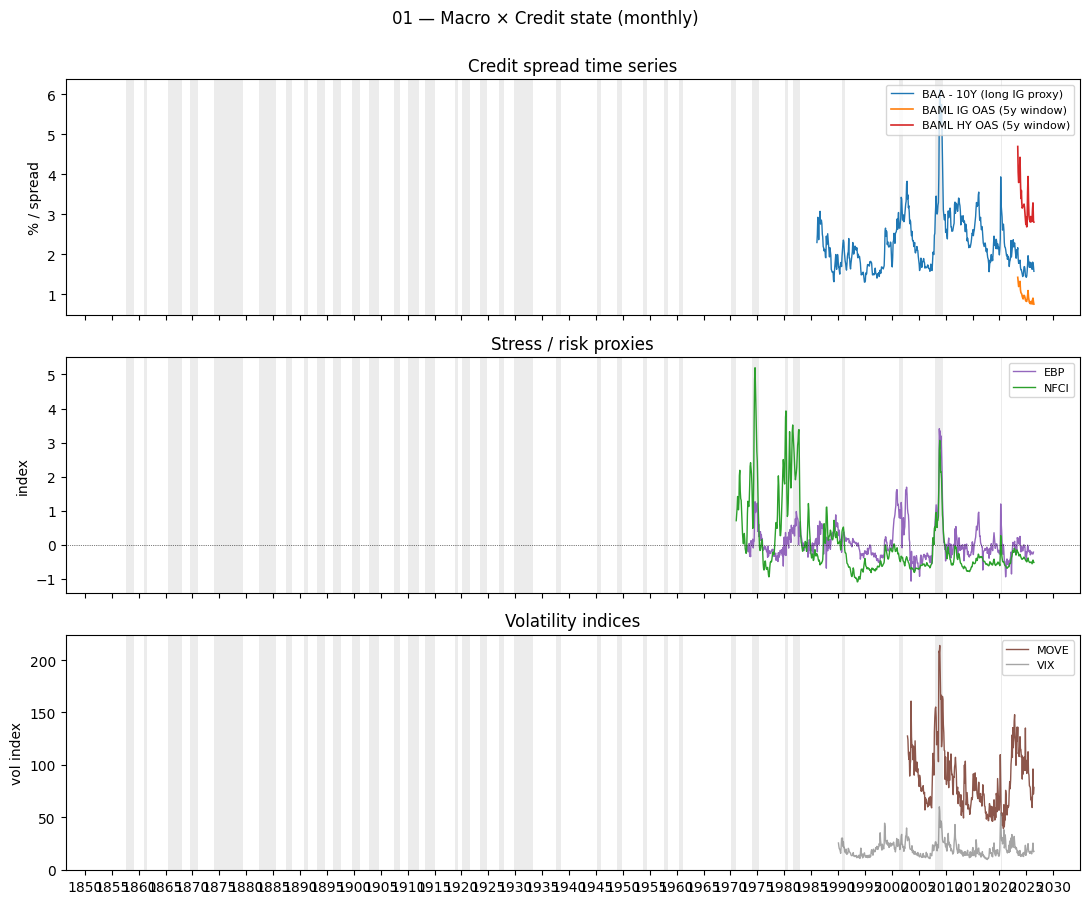

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

ax = axes[0]
ax.plot(monthly.index, monthly["BAA10Y"], color="tab:blue", lw=1.0, label="BAA - 10Y (long IG proxy)")
ax.plot(monthly.index, monthly["BAMLC0A0CM"], color="tab:orange", lw=1.2, label="BAML IG OAS (5y window)")
ax.plot(monthly.index, monthly["BAMLH0A0HYM2"], color="tab:red", lw=1.2, label="BAML HY OAS (5y window)")
ax.set_ylabel("% / spread")
ax.set_title("Credit spread time series")
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
ax.plot(monthly.index, monthly["ebp"], color="tab:purple", lw=1.0, label="EBP")
ax.plot(monthly.index, monthly["NFCI"], color="tab:green", lw=1.0, label="NFCI")
ax.axhline(0, color="black", lw=0.5, ls=":")
ax.set_ylabel("index")
ax.set_title("Stress / risk proxies")
ax.legend(loc="upper right", fontsize=8)

ax = axes[2]
ax.plot(monthly.index, monthly["MOVE"], color="tab:brown", lw=1.0, label="MOVE")
ax.plot(monthly.index, monthly["VIXCLS"], color="tab:gray", lw=1.0, label="VIX", alpha=0.7)
ax.set_ylabel("vol index")
ax.set_title("Volatility indices")
ax.legend(loc="upper right", fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

rec_mask = (regimes["recession"].reindex(monthly.index).fillna(0) == 1).values
for ax in axes:
    for start, end in _contiguous(monthly.index, rec_mask):
        ax.axvspan(start, end, color="gray", alpha=0.15, lw=0)

fig.suptitle("01 — Macro × Credit state (monthly)", y=1.00)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "timeseries_credit_stress_vol.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. レジーム別のスプレッド水準

In [11]:
regime_compare = pd.DataFrame(index=["all", "recession", "stress_high", "recession & stress_high", "normal"])
for spread_col in ["BAA10Y", "BAMLC0A0CM", "BAMLH0A0HYM2", "ebp"]:
    if spread_col not in monthly.columns:
        continue
    s = monthly[spread_col]
    rec = regimes["recession"] == 1
    stress = regimes["stress_high"] == 1
    regime_compare.loc["all", spread_col] = s.mean()
    regime_compare.loc["recession", spread_col] = s[rec].mean()
    regime_compare.loc["stress_high", spread_col] = s[stress].mean()
    regime_compare.loc["recession & stress_high", spread_col] = s[rec & stress].mean()
    regime_compare.loc["normal", spread_col] = s[~rec & ~stress].mean()

regime_compare.round(2)

,BAA10Y,BAMLC0A0CM,BAMLH0A0HYM2,ebp
all,2.27,0.95,3.27,0.06
recession,3.43,NaN,NaN,0.81
stress_high,3.66,NaN,NaN,1.39
recession & stress_high,4.13,NaN,NaN,1.71
normal,2.14,0.95,3.27,-0.07


## 8. パネル保存

後続 notebook (02 A1 SHAP / 03 A2 Robeco) で読み直せるよう parquet で保存。

In [12]:
monthly_out = RESULTS_DIR / "monthly_panel.parquet"
daily_out = RESULTS_DIR / "daily_panel.parquet"
regimes_out = RESULTS_DIR / "regimes.parquet"

monthly.to_parquet(monthly_out)
daily.to_parquet(daily_out)
regimes.astype({"ff_cycle": "string"}).to_parquet(regimes_out)

print("saved:")
for p in [monthly_out, daily_out, regimes_out]:
    print(" ", p, "->", round(p.stat().st_size / 1024, 1), "KB")

saved:
  /home/tarai/Research/FI-research/projects/00_exploration/results/01_macro_credit_state/monthly_panel.parquet -> 243.1 KB
  /home/tarai/Research/FI-research/projects/00_exploration/results/01_macro_credit_state/daily_panel.parquet -> 2113.8 KB
  /home/tarai/Research/FI-research/projects/00_exploration/results/01_macro_credit_state/regimes.parquet -> 26.0 KB


## 9. 次の一手

- `02_a1_shap_sketch.ipynb` で月次パネル + Robeco IG MultiFactor を従属変数に XGBoost/LightGBM + SHAP
- `03_a2_robeco_replication.ipynb` で Robeco 5 ファクターの Fama-MacBeth、EDGAR fundamentals マージ可能性
- どちらも `RESULTS_DIR / monthly_panel.parquet` を読み込む前提